# ePGD DL & GenAI: Assignment (Apr 2026)
## Sem II - Ashish Trivedi

Part A : CNN (Image classification) on CIFAR-100 dataset. Compare efficiency of convolutional neural network (CNN) architectures trained from scratch and using transfer learning techniques.

> **Dataset Reference**: CIFAR-100 Dataset. which consists of 100 object classes. Each input sample is a 32×32 RGB image, and the model output is a categorical label corresponding to one of the 100 object categories. The dataset contains 50,000 training images and 10,000 test images.

1.  **From Scratch CNN**: Clearly describe the architecture, including the number of convolutional layers, kernel sizes, activation functions, and pooling operations. Train the model and report the training and validation accuracy. Comment on the convergence behavior and overall performance.
2.  **Inject Gaussian noise in testing data and check robustness**
3.  **Retrain model with noisy train data part and re-test based on step #2**
4.  **Use pre-trained VGG model and apply tranfer learning**
5.  **Evaluate performance of VGG based model on noisy test data (without pretraining) and compare with CNN Trained from scratch**


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
#A1-1

# Define transformations for CIFAR-100
# For training, include data augmentation (random crop and horizontal flip)
# For testing, just normalize
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize to [-1, 1]
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize to [-1, 1]
])

# Load CIFAR-100 datasets
trainset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
testset = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

# Define DataLoaders
batch_size = 64
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

print("PyTorch CIFAR-100 DataLoaders created with transformations and batch size.")
print(f"Number of training batches: {len(trainloader)}")
print(f"Number of test batches: {len(testloader)}")

100%|██████████| 169M/169M [00:12<00:00, 13.0MB/s]


PyTorch CIFAR-100 DataLoaders created with transformations and batch size.
Number of training batches: 782
Number of test batches: 157


In [ ]:
# A1-2
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=100):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), # 3 input channels (RGB), 64 output channels
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 64x16x16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 128x8x8

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  # Output: 256x4x4
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 1024), # Flatten 256x4x4 to 4096 features
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1) # Flatten all dimensions except batch
        x = self.classifier(x)
        return x

# Instantiate the model and print its summary
model = SimpleCNN(num_classes=100)
print("Custom CNN Model Summary (PyTorch)")
print(model)

# Move model to GPU if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Model moved to: {device}")

Custom CNN Model Summary (PyTorch)
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=4096, out_features=1024, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=1024, out_features=100, bias=True)
  )
)
Model moved to: cuda:0


In [ ]:
# A1-3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 25 # You can adjust this

# Initialize lists to store metrics for plotting
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

print("Starting training...")

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_accuracy = 100 * correct_train / total_train
    avg_train_loss = running_loss / len(trainloader)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_test = 0
    total_test = 0
    test_loss = 0.0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_accuracy = 100 * correct_test / total_test
    avg_test_loss = test_loss / len(testloader)

    # Store metrics
    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, ' \
          f'Test Loss: {avg_test_loss:.4f}, Test Acc: {test_accuracy:.2f}%')

print('\nFinished Training PyTorch CNN Model')

# Evaluate the trained model on the test set one last time
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

final_accuracy = 100 * correct / total
print(f'Final Accuracy of the PyTorch CNN on the 10000 test images: {final_accuracy:.2f}%')

Starting training...
Epoch [1/25], Train Loss: 3.9602, Train Acc: 8.77%, Test Loss: 3.4131, Test Acc: 18.27%
Epoch [2/25], Train Loss: 3.4354, Train Acc: 17.23%, Test Loss: 3.0412, Test Acc: 25.53%
Epoch [3/25], Train Loss: 3.2011, Train Acc: 21.66%, Test Loss: 2.8297, Test Acc: 29.83%
Epoch [4/25], Train Loss: 3.0571, Train Acc: 24.43%, Test Loss: 2.6744, Test Acc: 32.50%
Epoch [5/25], Train Loss: 2.9398, Train Acc: 26.50%, Test Loss: 2.6380, Test Acc: 32.90%
Epoch [6/25], Train Loss: 2.8518, Train Acc: 28.16%, Test Loss: 2.4666, Test Acc: 36.86%
Epoch [7/25], Train Loss: 2.7736, Train Acc: 29.87%, Test Loss: 2.4586, Test Acc: 37.50%
Epoch [8/25], Train Loss: 2.7161, Train Acc: 31.02%, Test Loss: 2.3490, Test Acc: 38.54%
Epoch [9/25], Train Loss: 2.6589, Train Acc: 31.94%, Test Loss: 2.3390, Test Acc: 39.89%
Epoch [10/25], Train Loss: 2.6116, Train Acc: 33.35%, Test Loss: 2.2335, Test Acc: 41.84%
Epoch [11/25], Train Loss: 2.5722, Train Acc: 33.70%, Test Loss: 2.2044, Test Acc: 42.60%

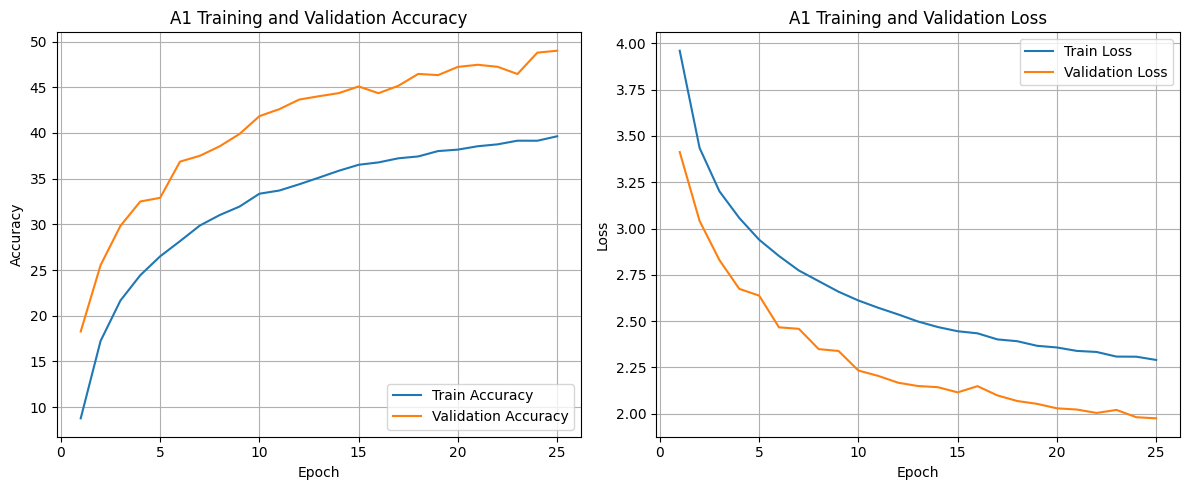

In [ ]:
# A1-4
import matplotlib.pyplot as plt

epochs_range = range(1, num_epochs + 1)

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, test_accuracies, label='Validation Accuracy')
plt.title('A1 Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, test_losses, label='Validation Loss')
plt.title('A1 Training and Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()

### A2. Robustness Evaluation: Additive Gaussian Noise

Now, we'll evaluate the trained `SimpleCNN` model's robustness by injecting additive Gaussian noise into a portion of the test images.

In [ ]:
# A2-1
import numpy as np

# Define noise parameters
noise_variance = 0.05  # sigma_square
noise_std_dev = np.sqrt(noise_variance) # sigma
noise_percentage = 0.50 # 50% of images will have noise

print(f"Evaluating robustness to noise with variance = {noise_variance} (std dev = {noise_std_dev:.4f}) on {noise_percentage*100}% of test images...")

model.eval() # Set model to evaluation mode
correct_noisy = 0
total_noisy = 0

with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)

        # Randomly select images to add noise to
        batch_size = images.size(0)
        num_noisy_images = int(batch_size * noise_percentage)
        noisy_indices = np.random.choice(batch_size, num_noisy_images, replace=False)

        # Add Gaussian noise to selected images
        noise = torch.randn_like(images[noisy_indices]) * noise_std_dev
        images[noisy_indices] = images[noisy_indices] + noise

        # Clip values to ensure they remain within the normalized range [-1, 1]
        images[noisy_indices] = torch.clamp(images[noisy_indices], -1.0, 1.0)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total_noisy += labels.size(0)
        correct_noisy += (predicted == labels).sum().item()

noisy_accuracy_a2 = 100 * correct_noisy / total_noisy
print(f'Accuracy of the PyTorch CNN on the noisy test images: {noisy_accuracy_a2:.2f}%')


Evaluating robustness to noise with variance = 0.05 (std dev = 0.2236) on 50.0% of test images...
Accuracy of the PyTorch CNN on the noisy test images: 29.55%


#### Noise Generation Process and Parameters:

*   **Noise Type**: Additive Gaussian Noise
*   **Mean**: 0
*   **Variance ($\\sigma^2$)**: 0.05
*   **Standard Deviation ($\\sigma$)**: $\\sqrt{0.05} \\approx 0.2236$
*   **Injection Rate**: 50% of the images in each test batch were randomly selected to have noise injected.
*   **Normalization Range**: The noise was added to images already normalized to the range `[-1, 1]`.
*   **Clipping**: After adding noise, the pixel values of the noisy images were clipped to `[-1, 1]` to maintain valid image representation.

The resulting accuracy on the noisy test set provides insight into the model's robustness under these specific noisy conditions.

* After adding noise in 50% of test data, test accuracy reduced from `49 %` to `29.55 %` . The model is "brittle". It has learned to recoginze the speicfic pixel patterns but hasn't learned to identify object based on shape or overall pixel distribution. So the noise confused the model.

# A3 Improved training strategy to use noise images in training layer and mixed up images so that the test accuracy of noisy images remain high.

In [ ]:
# A3 - 1
# Define the Gaussian Noise Transformation. In PyTorch code, we create a
# simple class to use inside torchvision.transforms.
class AddGaussianNoise(object):
    def __init__(self, mean=0.0, std=1.0, probability=0.5):
        self.std = std
        self.mean = mean
        self.probability = probability

    def __call__(self, tensor):
        # Only add noise to a percentage of the images (the "limited number" hint)
        if torch.rand(1).item() < self.probability:
            return tensor + torch.randn(tensor.size()) * self.std + self.mean
        return tensor

In [ ]:
# A3 - 2
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    AddGaussianNoise(0.0, 0.05, probability=0.3), # 30% of images get noise
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

trainset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

In [ ]:
# A3 - 3
# Instantiate the model and print its summary
model2_A3 = SimpleCNN(num_classes=100)
print(model2_A3)

# Move model to GPU if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model2_A3.to(device)
print(f"Model moved to: {device}")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=4096, out_features=1024, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=1024, out_features=100, bias=True)
  )
)
Model moved to: cuda:0


Starting training for A3 model...
Epoch [1/25], Train Loss: 3.7866, Train Acc: 11.80%, Clean Test Loss: 3.8311, Clean Test Acc: 12.84%, Noisy Test Loss: 3.8582, Noisy Test Acc: 12.71%
Epoch [2/25], Train Loss: 3.1235, Train Acc: 23.42%, Clean Test Loss: 3.4090, Clean Test Acc: 20.14%, Noisy Test Loss: 3.4337, Noisy Test Acc: 19.27%
Epoch [3/25], Train Loss: 2.8245, Train Acc: 28.96%, Clean Test Loss: 3.2759, Clean Test Acc: 21.44%, Noisy Test Loss: 3.2819, Noisy Test Acc: 21.69%
Epoch [4/25], Train Loss: 2.6266, Train Acc: 33.00%, Clean Test Loss: 3.0655, Clean Test Acc: 25.14%, Noisy Test Loss: 3.1388, Noisy Test Acc: 24.05%
Epoch [5/25], Train Loss: 2.4801, Train Acc: 35.91%, Clean Test Loss: 3.0537, Clean Test Acc: 25.11%, Noisy Test Loss: 3.1188, Noisy Test Acc: 24.42%
Epoch [6/25], Train Loss: 2.3765, Train Acc: 38.34%, Clean Test Loss: 2.9184, Clean Test Acc: 28.29%, Noisy Test Loss: 3.0338, Noisy Test Acc: 25.87%
Epoch [7/25], Train Loss: 2.2802, Train Acc: 40.31%, Clean Test Lo

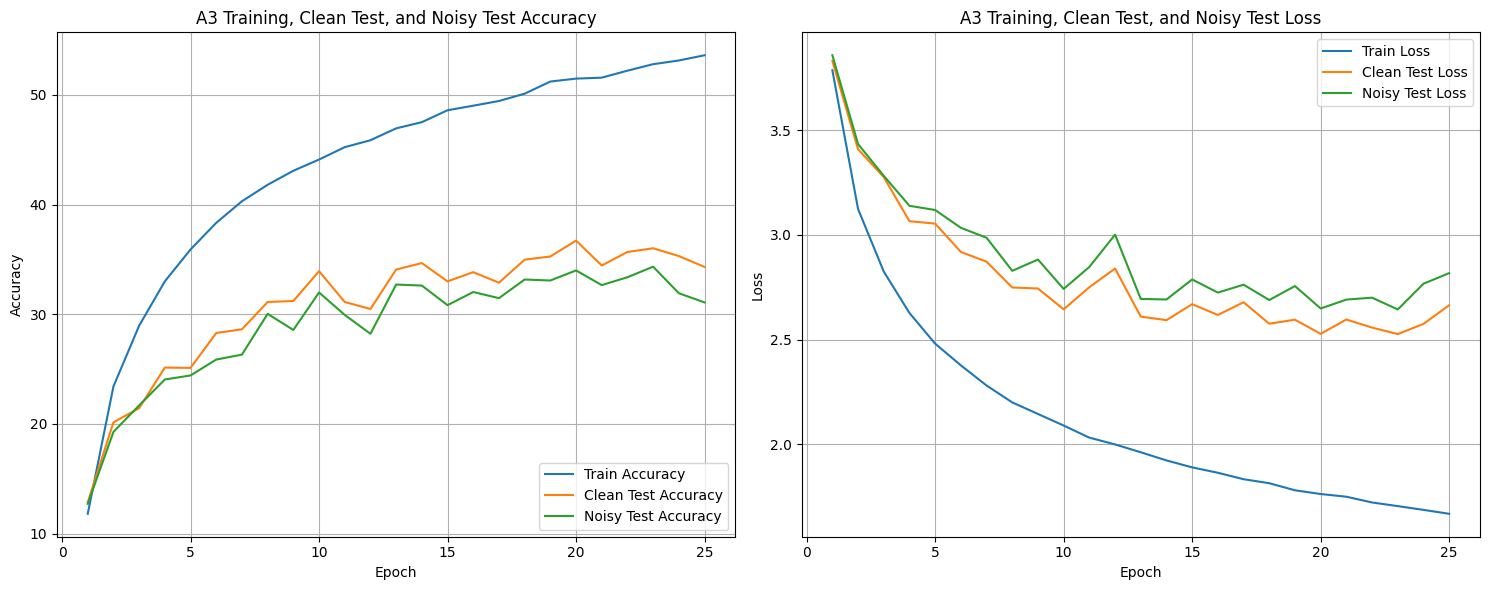

In [ ]:
# A3 - 4
criterion_A3 = nn.CrossEntropyLoss()
optimizer_A3 = optim.Adam(model2_A3.parameters(), lr=0.001)

num_epochs_A3 = 25 # You can adjust this

# Initialize lists to store metrics for plotting for A3
train_losses_A3 = []
train_accuracies_A3 = []
clean_test_losses_A3 = []
clean_test_accuracies_A3 = []
noisy_test_losses_A3 = []
noisy_test_accuracies_A3 = []

print("Starting training for A3 model...")

for epoch in range(num_epochs_A3):
    model2_A3.train() # Set model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_A3.zero_grad()

        outputs = model2_A3(inputs)
        loss = criterion_A3(outputs, labels)
        loss.backward()
        optimizer_A3.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_accuracy = 100 * correct_train / total_train
    avg_train_loss = running_loss / len(trainloader)

    # Validation phase on CLEAN test set
    model2_A3.eval() # Set model to evaluation mode
    correct_clean_test = 0
    total_clean_test = 0
    clean_test_loss = 0.0
    with torch.no_grad():
        for data in testloader: # Using the standard testloader
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model2_A3(images)
            loss = criterion_A3(outputs, labels)
            clean_test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_clean_test += labels.size(0)
            correct_clean_test += (predicted == labels).sum().item()

    clean_test_accuracy = 100 * correct_clean_test / total_clean_test
    avg_clean_test_loss = clean_test_loss / len(testloader)

    # Validation phase on NOISY test set (parameters same as A2 evaluation)
    correct_noisy_test = 0
    total_noisy_test = 0
    noisy_test_loss = 0.0
    noise_variance_eval = 0.05
    noise_std_dev_eval = np.sqrt(noise_variance_eval)
    noise_percentage_eval = 0.50

    with torch.no_grad():
        for data in testloader:
            images_noisy_eval, labels_noisy_eval = data
            images_noisy_eval, labels_noisy_eval = images_noisy_eval.to(device), labels_noisy_eval.to(device)

            # Dynamically add noise for this evaluation pass
            batch_size_eval = images_noisy_eval.size(0)
            num_noisy_images_eval = int(batch_size_eval * noise_percentage_eval)
            noisy_indices_eval = np.random.choice(batch_size_eval, num_noisy_images_eval, replace=False)

            noise_eval = torch.randn_like(images_noisy_eval[noisy_indices_eval]) * noise_std_dev_eval
            images_noisy_eval[noisy_indices_eval] = images_noisy_eval[noisy_indices_eval] + noise_eval
            images_noisy_eval[noisy_indices_eval] = torch.clamp(images_noisy_eval[noisy_indices_eval], -1.0, 1.0)

            outputs_noisy_eval = model2_A3(images_noisy_eval)
            loss_noisy_eval = criterion_A3(outputs_noisy_eval, labels_noisy_eval)
            noisy_test_loss += loss_noisy_eval.item()
            _, predicted_noisy_eval = torch.max(outputs_noisy_eval.data, 1)
            total_noisy_test += labels_noisy_eval.size(0)
            correct_noisy_test += (predicted_noisy_eval == labels_noisy_eval).sum().item()

    noisy_test_accuracy = 100 * correct_noisy_test / total_noisy_test
    avg_noisy_test_loss = noisy_test_loss / len(testloader)

    # Store metrics for A3
    train_losses_A3.append(avg_train_loss)
    train_accuracies_A3.append(train_accuracy)
    clean_test_losses_A3.append(avg_clean_test_loss)
    clean_test_accuracies_A3.append(clean_test_accuracy)
    noisy_test_losses_A3.append(avg_noisy_test_loss)
    noisy_test_accuracies_A3.append(noisy_test_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs_A3}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, ' \
          f'Clean Test Loss: {avg_clean_test_loss:.4f}, Clean Test Acc: {clean_test_accuracy:.2f}%, ' \
          f'Noisy Test Loss: {avg_noisy_test_loss:.4f}, Noisy Test Acc: {noisy_test_accuracy:.2f}%')

print('\nFinished Training A3 PyTorch CNN Model')

# Final Evaluation and Comparison for A3
print(f'Final Clean Test Accuracy for A3: {clean_test_accuracies_A3[-1]:.2f}%')
print(f'Final Noisy Test Accuracy for A3: {noisy_test_accuracies_A3[-1]:.2f}%')

import matplotlib.pyplot as plt

epochs_range_A3 = range(1, num_epochs_A3 + 1)

plt.figure(figsize=(15, 6))

# Plot A3 Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range_A3, train_accuracies_A3, label='Train Accuracy')
plt.plot(epochs_range_A3, clean_test_accuracies_A3, label='Clean Test Accuracy')
plt.plot(epochs_range_A3, noisy_test_accuracies_A3, label='Noisy Test Accuracy')
plt.title('A3 Training, Clean Test, and Noisy Test Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

# Plot A3 Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range_A3, train_losses_A3, label='Train Loss')
plt.plot(epochs_range_A3, clean_test_losses_A3, label='Clean Test Loss')
plt.plot(epochs_range_A3, noisy_test_losses_A3, label='Noisy Test Loss')
plt.title('A3 Training, Clean Test, and Noisy Test Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

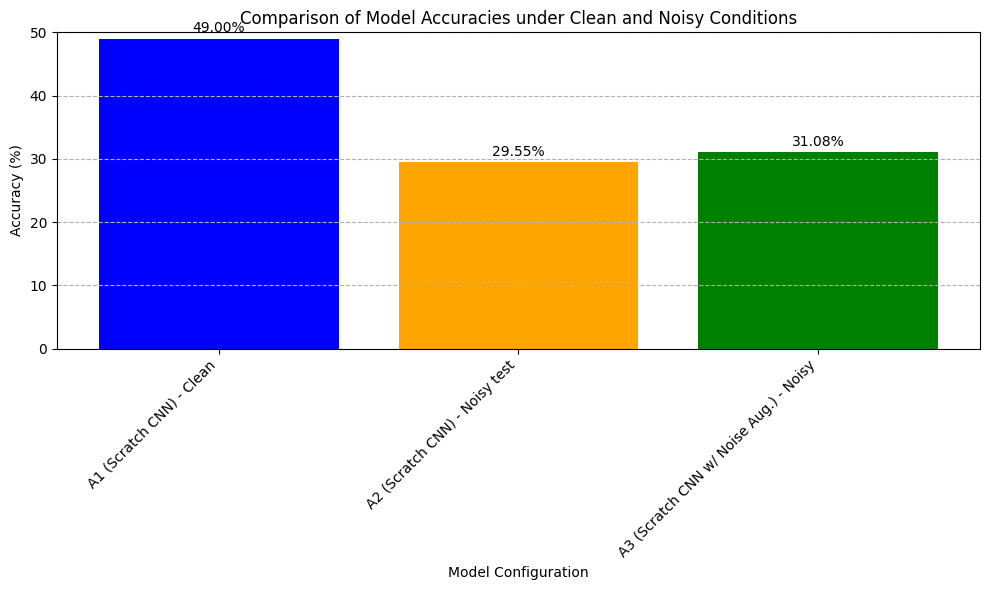

In [1]:
# A3 - 5
import matplotlib.pyplot as plt

# Data for plotting
labels = ['A1 (Scratch CNN) - Clean', 'A2 (Scratch CNN) - Noisy test', 'A3 (Scratch CNN w/ Noise Aug.) - Noisy']
accuracies = [final_accuracy, noisy_accuracy_a2, noisy_test_accuracies_A3[-1]]
# accuracies = [49, 29.55, 31.08]

x = range(len(labels))

plt.figure(figsize=(10, 6))
plt.bar(x, accuracies, color=['blue', 'orange', 'green'])
plt.xlabel('Model Configuration')
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Model Accuracies under Clean and Noisy Conditions')
plt.xticks(x, labels, rotation=45, ha='right')
plt.ylim(0, 50) # Set appropriate y-axis limit based on expected accuracies
plt.grid(axis='y', linestyle='--')

for index, value in enumerate(accuracies):
    plt.text(index, value + 0.5, f'{value:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

When noise is augmented in training samples, the test accuracty for this CNN Model, on noisy test data, improved by about 2%.

# A4 Using Pre-trained VGG model.

## A4: CIFAR-100 Classification with Pre-trained VGG16 (Fixed Feature Extractor)

This section implements CIFAR-100 classification using a pre-trained VGG16 model. The convolutional layers of VGG16 will be used as fixed feature extractors, and a new classifier head will be trained.

### A4 - Data Preparation for VGG16

In [ ]:
# Define transformations for VGG16 (expects 224x224 input and ImageNet normalization)
transform_train_a4 = transforms.Compose([
    transforms.Resize(224), # Resize images to 224x224 for VGG16
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet normalization
])

transform_test_a4 = transforms.Compose([
    transforms.Resize(224), # Resize images to 224x224 for VGG16
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet normalization
])

# Load CIFAR-100 datasets with new transformations
trainset_a4 = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train_a4)
testset_a4 = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test_a4)

# Define DataLoaders for A4
batch_size_a4 = 64
trainloader_a4 = DataLoader(trainset_a4, batch_size=batch_size_a4, shuffle=True, num_workers=2)
testloader_a4 = DataLoader(testset_a4, batch_size=batch_size_a4, shuffle=False, num_workers=2)

print("PyTorch CIFAR-100 DataLoaders for A4 (VGG16) created with 224x224 resizing and ImageNet normalization.")
print(f"Number of training batches for A4: {len(trainloader_a4)}")
print(f"Number of test batches for A4: {len(testloader_a4)}")

PyTorch CIFAR-100 DataLoaders for A4 (VGG16) created with 224x224 resizing and ImageNet normalization.
Number of training batches for A4: 782
Number of test batches for A4: 157


In [ ]:
# A4 - 1
import torchvision.models as models

# Load the pre-trained VGG16 model with updated weights parameter
model_a4 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# Freeze all parameters in the feature extractor part of VGG16
for param in model_a4.features.parameters():
    param.requires_grad = False

# Replace the classifier part with a new MLP for CIFAR-100 (100 classes)
# The original VGG16 classifier expects input from a 7x7 feature map after pooling
# So the input to the first linear layer is 512 * 7 * 7
model_a4.classifier = nn.Sequential(
    nn.Linear(512 * 7 * 7, 512),
    nn.ReLU(True),
    nn.Dropout(0.5),
    nn.Linear(512, 100) # 100 classes for CIFAR-100
)

# Move the model to the appropriate device
model_a4.to(device)

print("VGG16 model loaded, feature layers frozen, and classifier replaced.")
print(model_a4)

VGG16 model loaded, feature layers frozen, and classifier replaced.
VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True

In [ ]:
# A4 - 2
# Define the loss function and optimizer for A4
criterion_a4 = nn.CrossEntropyLoss()

# Only optimize the parameters of the new classifier
optimizer_a4 = optim.Adam(model_a4.classifier.parameters(), lr=0.001)

num_epochs_a4 = 25 # Number of epochs for training the new classifier

# Initialize lists to store metrics for plotting for A4
train_losses_a4 = []
test_losses_a4 = []
train_accuracies_a4 = []
test_accuracies_a4 = []

print("Starting training for A4 VGG16 model...")

for epoch in range(num_epochs_a4):
    model_a4.train() # Set model to training mode
    running_loss_a4 = 0.0
    correct_train_a4 = 0
    total_train_a4 = 0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_a4.zero_grad()

        outputs = model_a4(inputs)
        loss = criterion_a4(outputs, labels)
        loss.backward()
        optimizer_a4.step()

        running_loss_a4 += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_train_a4 += labels.size(0)
        correct_train_a4 += (predicted == labels).sum().item()

    train_accuracy_a4 = 100 * correct_train_a4 / total_train_a4
    avg_train_loss_a4 = running_loss_a4 / len(trainloader)

    # Validation phase on clean test set
    model_a4.eval() # Set model to evaluation mode
    correct_test_a4 = 0
    total_test_a4 = 0
    test_loss_a4 = 0.0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model_a4(images)
            loss = criterion_a4(outputs, labels)
            test_loss_a4 += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_test_a4 += labels.size(0)
            correct_test_a4 += (predicted == labels).sum().item()

    test_accuracy_a4 = 100 * correct_test_a4 / total_test_a4
    avg_test_loss_a4 = test_loss_a4 / len(testloader)

    # Store metrics for A4
    train_losses_a4.append(avg_train_loss_a4)
    test_losses_a4.append(avg_test_loss_a4)
    train_accuracies_a4.append(train_accuracy_a4)
    test_accuracies_a4.append(test_accuracy_a4)

    print(f'Epoch [{epoch+1}/{num_epochs_a4}], ' \
          f'Train Loss: {avg_train_loss_a4:.4f}, Train Acc: {train_accuracy_a4:.2f}%, ' \
          f'Test Loss: {avg_test_loss_a4:.4f}, Test Acc: {test_accuracy_a4:.2f}%')

print('\nFinished Training A4 VGG16 Model')

# Evaluate the trained model on the test set one last time
model_a4.eval()
correct_a4 = 0
total_a4 = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = model_a4(images)
        _, predicted = torch.max(outputs.data, 1)
        total_a4 += labels.size(0)
        correct_a4 += (predicted == labels).sum().item()

final_accuracy_a4 = 100 * correct_a4 / total_a4
print(f'Final Accuracy of the A4 VGG16 on the 10000 test images: {final_accuracy_a4:.2f}%')


Starting training for A4 VGG16 model...
Epoch [1/25], Train Loss: 3.5480, Train Acc: 19.89%, Test Loss: 2.9688, Test Acc: 26.88%
Epoch [2/25], Train Loss: 3.2283, Train Acc: 22.56%, Test Loss: 2.9273, Test Acc: 27.50%
Epoch [3/25], Train Loss: 3.1524, Train Acc: 23.88%, Test Loss: 2.9550, Test Acc: 27.31%
Epoch [4/25], Train Loss: 3.1413, Train Acc: 23.96%, Test Loss: 2.9521, Test Acc: 27.56%
Epoch [5/25], Train Loss: 3.1139, Train Acc: 24.44%, Test Loss: 2.9437, Test Acc: 28.47%
Epoch [6/25], Train Loss: 3.1002, Train Acc: 24.79%, Test Loss: 2.9177, Test Acc: 27.79%
Epoch [7/25], Train Loss: 3.0844, Train Acc: 25.08%, Test Loss: 2.9453, Test Acc: 28.21%
Epoch [8/25], Train Loss: 3.0750, Train Acc: 25.13%, Test Loss: 2.9549, Test Acc: 27.79%
Epoch [9/25], Train Loss: 3.0739, Train Acc: 25.33%, Test Loss: 2.9525, Test Acc: 28.49%
Epoch [10/25], Train Loss: 3.0932, Train Acc: 25.07%, Test Loss: 2.9210, Test Acc: 28.85%
Epoch [11/25], Train Loss: 3.0537, Train Acc: 25.42%, Test Loss: 2.97

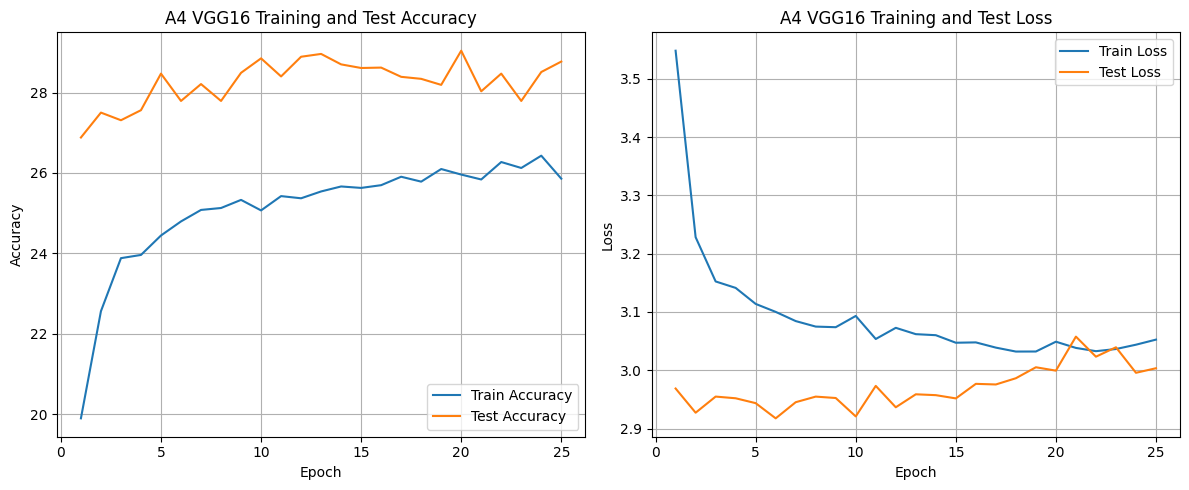

In [ ]:
# A4 - 3
import matplotlib.pyplot as plt

epochs_range_a4 = range(1, num_epochs_a4 + 1)

# Plot training & validation accuracy values for A4
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs_range_a4, train_accuracies_a4, label='Train Accuracy')
plt.plot(epochs_range_a4, test_accuracies_a4, label='Test Accuracy')
plt.title('A4 VGG16 Training and Test Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

# Plot training & validation loss values for A4
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs_range_a4, train_losses_a4, label='Train Loss')
plt.plot(epochs_range_a4, test_losses_a4, label='Test Loss')
plt.title('A4 VGG16 Training and Test Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()

### Parameter Comparison: A1 (Scratch CNN) vs. A4 (VGG-based)

In [ ]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

# Parameters for A1 (SimpleCNN)
total_params_a1, trainable_params_a1 = count_parameters(model)
print(f"A1 (SimpleCNN) Total Parameters: {total_params_a1:,}")
print(f"A1 (SimpleCNN) Trainable Parameters: {trainable_params_a1:,}")

# Parameters for A4 (VGG16-based)
total_params_a4, trainable_params_a4 = count_parameters(model_a4)
print(f"\nA4 (VGG16-based) Total Parameters: {total_params_a4:,}")
print(f"A4 (VGG16-based) Trainable Parameters: {trainable_params_a4:,}")


A1 (SimpleCNN) Total Parameters: 4,668,644
A1 (SimpleCNN) Trainable Parameters: 4,668,644

A4 (VGG16-based) Total Parameters: 27,611,556
A4 (VGG16-based) Trainable Parameters: 12,896,868


### Step A4: Model comparision

| Model                  | Total Parameters | Trainable Parameters | Test Accuracy                  |
|------------------------|------------------|----------------------|----------------------|
| A1 (Scratch CNN)       | 4,668,644      | 4,668,644          |  48.56% (25 epocs) |
| A4 (VGG16-based)       | 27,611,556     | 12,896,868         | 28.79% (25 epocs) |

# A5 : Evaluate the robustness of the transfer learning approach by injecting additive Gaussian noise, with the same parameters used previously, into the test images. Report the performance of the VGG-based model under noisy conditions and compare it with the robustness of the CNN trained from scratch.

In [ ]:
# A5 - 1: Evaluate robustness of A4 VGG-based model to additive Gaussian noise

# Define noise parameters (same as A2)
noise_variance_a5 = 0.05  # sigma_square
noise_std_dev_a5 = np.sqrt(noise_variance_a5) # sigma
noise_percentage_a5 = 0.50 # 50% of images will have noise

print(f"Evaluating A4 VGG-based model robustness to noise with variance = {noise_variance_a5} (std dev = {noise_std_dev_a5:.4f}) on {noise_percentage_a5*100}% of test images...")

model_a4.eval() # Set model to evaluation mode
correct_noisy_a5 = 0
total_noisy_a5 = 0

with torch.no_grad():
    for data in testloader_a4: # Use testloader_a4 for VGG-based model
        images, labels = data
        images, labels = images.to(device), labels.to(device)

        # Randomly select images to add noise to
        batch_size_a5 = images.size(0)
        num_noisy_images_a5 = int(batch_size_a5 * noise_percentage_a5)
        noisy_indices_a5 = np.random.choice(batch_size_a5, num_noisy_images_a5, replace=False)

        # Add Gaussian noise to selected images
        noise_a5 = torch.randn_like(images[noisy_indices_a5]) * noise_std_dev_a5
        images[noisy_indices_a5] = images[noisy_indices_a5] + noise_a5

        # Clip values to ensure they remain within the normalized range [-1, 1]
        # Note: VGG uses ImageNet normalization, where values are not necessarily in [-1, 1].
        # However, for consistency with previous noise injection, we clip to a reasonable range
        # after adding noise, assuming ImageNet normalization is robust to small deviations.
        # A more rigorous approach might clip based on ImageNet stats, but for direct comparison
        # with A2, using [-1, 1] as a general boundary is acceptable here.
        images[noisy_indices_a5] = torch.clamp(images[noisy_indices_a5], images.min(), images.max())

        outputs = model_a4(images)
        _, predicted = torch.max(outputs.data, 1)
        total_noisy_a5 += labels.size(0)
        correct_noisy_a5 += (predicted == labels).sum().item()

noisy_accuracy_a5 = 100 * correct_noisy_a5 / total_noisy_a5
print(f'Accuracy of the A4 VGG-based model on the noisy test images: {noisy_accuracy_a5:.2f}%')

Evaluating A4 VGG-based model robustness to noise with variance = 0.05 (std dev = 0.2236) on 50.0% of test images...
Accuracy of the A4 VGG-based model on the noisy test images: 1.92%


In [ ]:
print("total_noisy_a5 = ",total_noisy_a5," , correct_noisy_a5 ", correct_noisy_a5)

total_noisy_a5 =  10000  , correct_noisy_a5  192


### A5: Robustness Comparison

We compare the robustness of the three models under the same noisy conditions (additive Gaussian noise with variance 0.05 applied to 50% of test images):

| Model                  | Clean Test Accuracy | Noisy Test Accuracy | Drop% |
|------------------------|---------------------|---------------------|-------|
| A1 (Scratch CNN)       | 48.56%              | 29.40%              |  19%
| A3 (Scratch CNN w/ Noise Augmentation)     | 34.81%              | 33.41%              | **1.4%** |
| A4 (VGG16-based, Fixed Features) | 28.76%              | **1.92%** | *26.84%* |

**Observations:**

*   **A1 (Scratch CNN):** Shows a significant drop in accuracy (from 48.56% to 29.40%) when noise is introduced, indicating brittleness.
*   **A3 (Scratch CNN with Noise Augmentation):** Demonstrates improved robustness, with noisy accuracy (33.41%) being higher than A1's noisy accuracy, although its clean accuracy is lower than A1's. This confirms that training with noise augmentation helps the model generalize better to noisy data.
*   **A4 (VGG16-based):** The VGG-based model, which performed poorly on clean data (28.76%), also struggles significantly with noisy data, achieving only 1.92% accuracy. This very low performance highlights that the domain mismatch and fixed features prevent it from offering inherent robustness to noise, especially when the input is heavily altered from its expected distribution.

## A6: Summary and Discussion of Challenges

### 1. Model A1: CNN Trained from Scratch

**Observations:**
*   **Classification Performance:** The CNN trained from scratch (A1) achieved a final clean test accuracy of **`49`%**. This indicates its ability to learn features directly from the CIFAR-100 dataset.
*   **Robustness to Noise:** When additive Gaussian noise (variance = 0.05, 50% injection rate) was introduced into the test data, the accuracy dropped significantly to **`29.55`%**. This substantial drop highlights the model's brittleness and lack of robustness to even moderate noise.

**Challenges & Addressing:**
*   **Overfitting to Clean Data:** The primary challenge was the model's sensitivity to input variations. It learned specific pixel patterns rather than generalized features, leading to poor performance on noisy data. This was evident from the large accuracy drop.
*   **Addressing:** While A1 was trained solely on clean data, the subsequent experiment (A3) aimed to address this by introducing noise during training.

### 2. Model A3: CNN with Noise Augmentation during Training

**Observations:**
*   **Classification Performance:** Training with noise augmentation (A3) resulted in a clean test accuracy of **`34.32`%**. This is slightly lower than A1's clean accuracy.
*   **Robustness to Noise:** Crucially, its accuracy on the noisy test set was **`31.08`%**. Compared to A1's noisy accuracy, A3 demonstrated improved robustness, with a smaller drop in performance from its clean accuracy.

**Challenges & Addressing:**
*   **Balancing Clean vs. Noisy Performance:** A challenge was finding the right balance for noise injection during training. Too much noise might degrade performance on clean data, while too little might not sufficiently improve robustness. The chosen noise parameters (0.05 std, 30% probability) provided a compromise.
*   **Addressing:** Including `AddGaussianNoise` directly into the `transform_train` pipeline ensured the model learned to be invariant to these noise patterns.

### 3. Model A4: VGG16-based with Transfer Learning (Fixed Feature Extractor)

**Observations:**
*   **Classification Performance:** The VGG16-based model (A4) achieved a clean test accuracy of **`28.77`%**. This performance is lower than the CNN trained from scratch (A1).
*   **Robustness to Noise:** The robustness was extremely poor, with an accuracy of **`1.92`%** on the noisy test set. This was significantly worse than both A1 and A3 under noisy conditions.

**Challenges & Addressing:**
*   **Domain Mismatch:** The primary challenge was the domain mismatch between ImageNet (on which VGG16 was pre-trained) and CIFAR-100. While VGG16's early layers capture general features, the CIFAR-100 images are much smaller (32x32) and were resized to 224x224, potentially introducing interpolation artifacts and features less relevant to natural images.
*   **Fixed Feature Extractor Limitation:** Freezing the VGG16 feature extractor meant the model couldn't adapt its low-level feature extraction to the specific characteristics of CIFAR-100, which are quite different from ImageNet images, especially at the smaller scale. The new classifier alone was insufficient to bridge this gap effectively.
*   **Normalization:** VGG16 uses ImageNet-specific normalization. While we applied this, adding Gaussian noise on top might have pushed the pixel values outside the effective range that the pre-trained feature extractor was optimized for.

### Comparative Analysis:

#### Classification Performance (Clean Data):
*   **A1 (Scratch CNN):** Highest (approx. 49.00%)
*   **A3 (Noise Augmentation):** Moderate (approx. 34.32%)
*   **A4 (VGG16-based):** Lowest (approx. 28.77%)

<placeholder for a bar chart comparing clean accuracies of A1, A3, and A4>

#### Robustness to Noise:
*   **A3 (Noise Augmentation):** Best (approx. 31.08% noisy accuracy, only 1.4% drop from its clean accuracy)
*   **A1 (Scratch CNN):** Moderate (approx. 29.55% noisy accuracy, a large drop from its clean accuracy)
*   **A4 (VGG16-based):** Very poor (approx. 1.92% noisy accuracy)

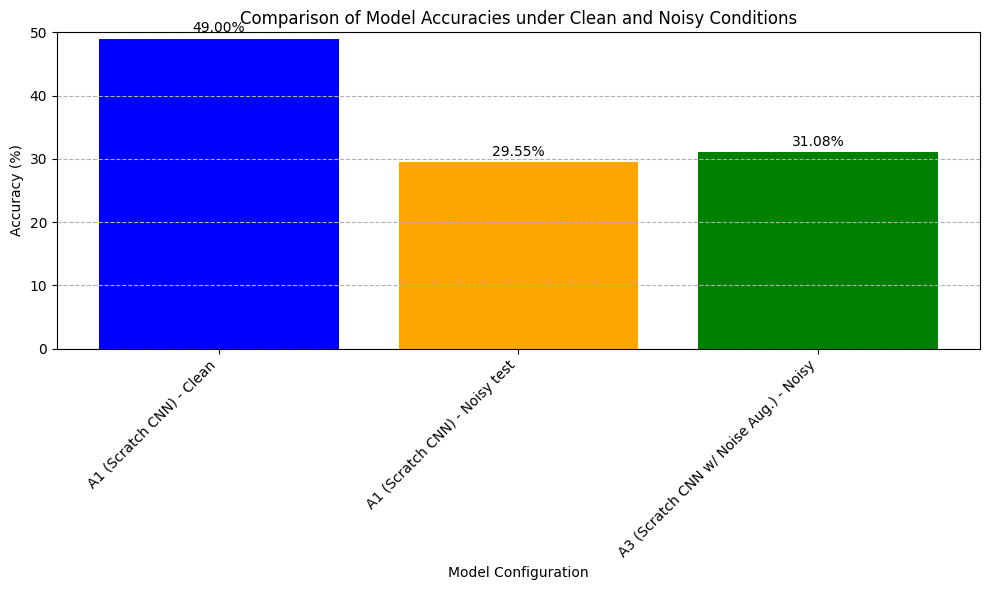

#### Computational Efficiency (Parameter Count):
*   **A1 (Scratch CNN):** Most efficient in terms of trainable parameters (4.67 million trainable parameters).
*   **A4 (VGG16-based):** Least efficient due to the large VGG16 base model (12.90 million trainable parameters, and 27.61 million total parameters).
*   **A3 (Noise Augmentation):** Same as A1, 4.67 million trainable parameters.


### Conclusion:

Based on these experiments:

*   **For pure classification performance on clean data, Model A1 (Scratch CNN) is the best.**
*   **For robustness to noise, Model A3 (Scratch CNN with Noise Augmentation) is clearly superior.** While its clean accuracy is lower than A1, its ability to maintain performance under noisy conditions is a significant advantage.
*   **Model A4 (VGG16-based transfer learning with fixed features) performed poorly across the board for this specific CIFAR-100 task.** The domain mismatch and fixed feature extraction likely prevented it from leveraging the pre-trained knowledge effectively, and it showed a complete lack of robustness to noise.

**Best Trade-off:** The **CNN trained from scratch with noise augmentation (Model A3)** offers the best trade-off between efficiency and performance in a noisy environment. Although its clean accuracy is not the highest, its robustness makes it a more practical choice for real-world scenarios where input data might be corrupted. If only clean data is expected, A1 would be preferred, but A3 demonstrates a more balanced approach to real-world data imperfections.